# **Data Preprocessing and Data Analysis**



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Load your exported CSV into a pandas DataFrame
df = pd.read_csv('market-dashboard.csv')

# 2. Pre-processing: Feature Engineering (Required for Part C.b)
# We calculate 'Order Book Imbalance' (OBI) to see if buyers or sellers are stronger.
# OBI is calculated as the difference between total bid and total ask, divided by their sum.
df['obi'] = (df['total_bid'] - df['total_ask']) / (df['total_bid'] + df['total_ask'])
df['obi'] = df['obi'].fillna(0) # Handling division by zero by replacing NaN values with 0

# 3. Standardization (Required for Distance-based models like K-Means)
# We select the features that will be used for clustering.
features = ['diff_percent', 'ppl_dominance', 'obi']
# Initialize the StandardScaler to standardize the features.
scaler = StandardScaler()
# Fit the scaler to the selected features and transform them, storing the result in X_scaled.
X_scaled = scaler.fit_transform(df[features])

print(f"Dataset Pre-processed: {X_scaled.shape[0]} rows ready for AI.")

# **Findind the optimum number of Clusters**

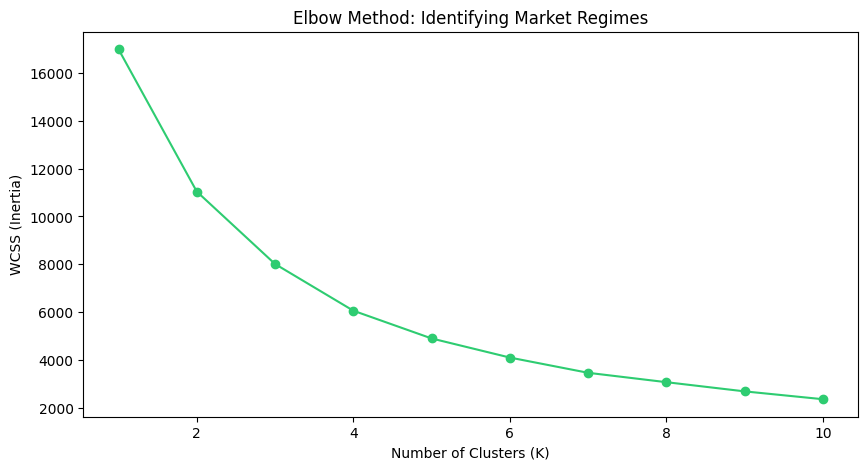

In [ ]:
# WCSS = Within-Cluster-Sum-of-Squares
# Initialize an empty list to store WCSS values for different numbers of clusters.
wcss = []
# Loop through a range of potential cluster numbers (from 1 to 10).
for i in range(1, 11):
    # Initialize KMeans with the current number of clusters, 'k-means++' initialization for centroids,
    # and a fixed random state for reproducibility.
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    # Fit the KMeans model to the scaled data.
    kmeans.fit(X_scaled)
    # Append the WCSS (inertia) for the current number of clusters to the wcss list.
    wcss.append(kmeans.inertia_)

# Create a figure for the plot with a specified size.
plt.figure(figsize=(10, 5))
# Plot the WCSS values against the number of clusters.
plt.plot(range(1, 11), wcss, marker='o', color='#2ecc71')
# Set the title of the plot.
plt.title('Elbow Method: Identifying Market Regimes')
# Set the x-axis label.
plt.xlabel('Number of Clusters (K)')
# Set the y-axis label.
plt.ylabel('WCSS (Inertia)')
# Display the plot.
plt.show()

# **K-Means Clustering**

In [ ]:
from sklearn.metrics import silhouette_score

# Assuming K=4 based on the elbow method plot from the previous step
# Initialize the KMeans model with 4 clusters and a fixed random state for reproducibility.
final_model = KMeans(n_clusters=4, random_state=42, n_init=10)
# Fit the KMeans model to the scaled data and predict cluster assignments for each data point.
df['cluster'] = final_model.fit_predict(X_scaled)

# Test: Silhouette Score (Higher is better, closer to 1)
# Calculate the silhouette score to evaluate the quality of the clustering.
score = silhouette_score(X_scaled, df['cluster'])
# Print the calculated silhouette score, formatted to four decimal places.
print(f"Software Testing Result: Silhouette Score = {score:.4f}")

Software Testing Result: Silhouette Score = 0.3946


In [ ]:
# Grouping the original DataFrame by the assigned cluster and calculating the mean of the features
# This helps to understand the 'personality' or characteristics of each market mood/regime.
interpretation = df.groupby('cluster')[features].mean()
# Print a header for the interpretation table.
print("--- Market Regime Personalities ---")
# Display the DataFrame showing the mean feature values for each cluster.
print(interpretation)

--- Market Regime Personalities ---
         diff_percent  ppl_dominance       obi
cluster                                       
0           29.042939      39.199439  0.211421
1         -274.874179      -1.075929 -0.512236
2           30.337308      -3.516185  0.214160
3        -1736.746742      -8.153596 -0.878237


# **Visualizing the Clusters**

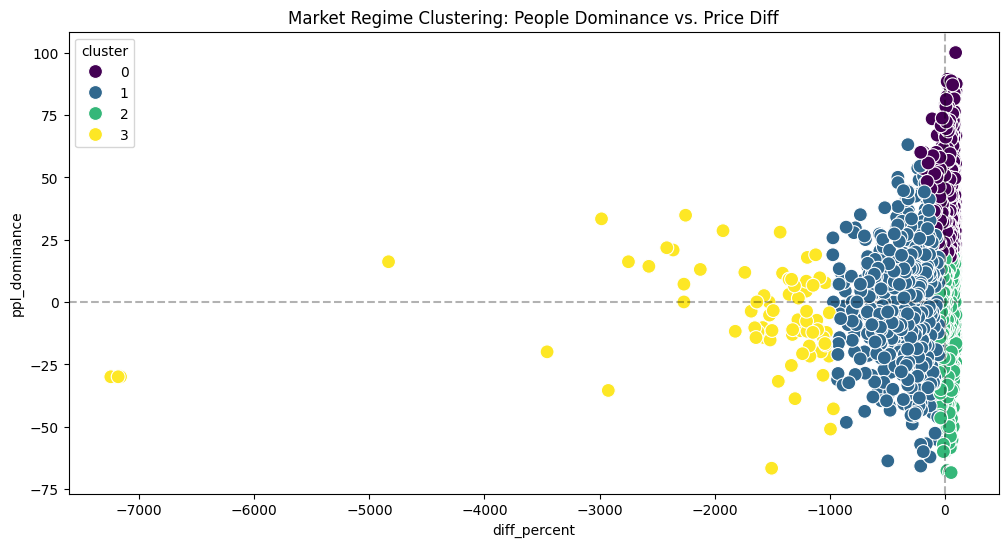

In [ ]:
# Create a figure for the plot with a specified size.
plt.figure(figsize=(12, 6))
# Create a scatter plot using seaborn.
# 'diff_percent' on the x-axis, 'ppl_dominance' on the y-axis.
# Points are colored according to their 'cluster' assignment using the 'viridis' palette.
# 's=100' sets the size of the markers.
sns.scatterplot(data=df, x='diff_percent', y='ppl_dominance', hue='cluster', palette='viridis', s=100)
# Set the title of the plot.
plt.title('Market Regime Clustering: People Dominance vs. Price Diff')
# Add a horizontal line at y=0 to indicate the baseline for 'ppl_dominance'.
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
# Add a vertical line at x=0 to indicate the baseline for 'diff_percent'.
plt.axvline(0, color='black', linestyle='--', alpha=0.3)
# Display the plot.
plt.show()

In [ ]:
import plotly.express as px

# Create an interactive 3D scatter plot using plotly.express.
# 'diff_percent' on the x-axis, 'ppl_dominance' on the y-axis, and 'obi' on the z-axis.
# Points are colored according to their 'cluster' assignment.
# Set the title of the plot and customize the label for the color legend.
# 'opacity=0.7' sets the transparency of the markers.
fig = px.scatter_3d(df, x='diff_percent', y='ppl_dominance', z='obi',
                    color='cluster',
                    title='3D Market Regime Discovery',
                    labels={'cluster': 'Regime Type'},
                    opacity=0.7)
# Display the interactive 3D plot.
fig.show()